# NYC Taxi Demand Forecasting — Model Development

This notebook develops and evaluates models for forecasting Yellow Taxi pickup demand one hour ahead at the zone level. Models are evaluated using chronological data splits and compared against simple historical baselines to determine whether learned models provide meaningful improvements over existing demand patterns.

## Objective

1. Load and validate the feature-engineered modeling dataset.
2. Construct chronological training, validation, and test periods.
3. Establish naive forecasting baselines using recent historical demand.
4. Train and evaluate machine learning models using the engineered feature set.
5. Compare model performance using appropriate regression metrics.
6. Analyze forecast errors and identify opportunities for further improvement.

## 1. Imports

Load the Python libraries used for dataset preparation, model development, and evaluation.

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from pathlib import Path

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor


In [87]:
from pathlib import Path

figures_dir = Path("../reports/figures")

figures_dir.mkdir(parents=True, exist_ok=True)

## 2. Load Modeling Dataset

Load the feature-engineered zone-hour dataset produced in the previous notebook and verify its structure before model development.

In [47]:
processed_dir = Path("../data/processed")
data_path = processed_dir / "yellow_taxi_modeling_features_2025.parquet"

data = pd.read_parquet(data_path)

data.head()

,pickup_hour,PULocationID,trip_count,hour,day_of_week,month,day_of_month,is_weekend,lag_1,lag_24,lag_168,rolling_mean_24,rolling_mean_168,is_holiday
0,2025-01-08 00:00:00,4,3,0,2,1,8,0,0.0,0.0,28.0,2.500000,4.988095,0
1,2025-01-08 01:00:00,4,3,1,2,1,8,0,3.0,1.0,54.0,2.625000,4.839286,0
2,2025-01-08 02:00:00,4,2,2,2,1,8,0,3.0,1.0,52.0,2.708333,4.535714,0
3,2025-01-08 03:00:00,4,0,3,2,1,8,0,2.0,0.0,42.0,2.750000,4.238095,0
4,2025-01-08 04:00:00,4,0,4,2,1,8,0,0.0,0.0,32.0,2.750000,3.988095,0


In [48]:
print("Shape:", data.shape)
print("Date range:", data["pickup_hour"].min(), "to", data["pickup_hour"].max())
print("Zones:", data["PULocationID"].nunique())
print("Missing values:", data.isna().sum().sum())

Shape: (1495008, 14)
Date range: 2025-01-08 00:00:00 to 2025-12-31 23:00:00
Zones: 174
Missing values: 0


## 3. Define Chronological Data Splits

Split the modeling dataset chronologically rather than randomly. Because the objective is to forecast future demand from historical information, random train-test splitting would allow later observations to influence model development while evaluating performance on earlier periods.

January through September are used for training, October and November for validation, and December is held out as the final test period.

In [49]:
train = data[
    data["pickup_hour"] < "2025-10-01"
].copy()

validation = data[
    (data["pickup_hour"] >= "2025-10-01") &
    (data["pickup_hour"] < "2025-12-01")
].copy()

test = data[
    data["pickup_hour"] >= "2025-12-01"
].copy()

In [50]:
for name, split in [
    ("Train", train),
    ("Validation", validation),
    ("Test", test)
]:
    print(
        f"{name}: "
        f"{len(split):,} rows | "
        f"{split['pickup_hour'].min()} to "
        f"{split['pickup_hour'].max()}"
    )

Train: 1,110,816 rows | 2025-01-08 00:00:00 to 2025-09-30 23:00:00
Validation: 254,736 rows | 2025-10-01 00:00:00 to 2025-11-30 23:00:00
Test: 129,456 rows | 2025-12-01 00:00:00 to 2025-12-31 23:00:00


In [51]:
print("Total rows:", f"{len(data):,}")
print(
    "Rows across splits:",
    f"{len(train) + len(validation) + len(test):,}"
)

Total rows: 1,495,008
Rows across splits: 1,495,008


## 4. Establish Naive Forecasting Baselines

Evaluate simple historical forecasting strategies on the validation period before training machine learning models. These baselines establish how accurately demand can be predicted using recent observations alone and provide a meaningful benchmark that learned models must outperform.

In [52]:
def evaluate_forecast(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    return {
        "MAE": mae,
        "RMSE": rmse
    }

In [53]:
baseline_predictions = {
    "Previous Hour": validation["lag_1"],
    "Previous Day": validation["lag_24"],
    "Previous Week": validation["lag_168"]
}

baseline_results = []

for name, predictions in baseline_predictions.items():
    metrics = evaluate_forecast(
        validation["trip_count"],
        predictions
    )

    baseline_results.append({
        "Model": name,
        **metrics
    })

baseline_results = pd.DataFrame(baseline_results)

baseline_results

,Model,MAE,RMSE
0,Previous Hour,8.755869,22.082270
1,Previous Day,10.236233,29.563017
2,Previous Week,7.710964,20.886584


## 5. Compare Baseline Performance

Compare validation errors across the naive forecasting strategies to identify the strongest historical benchmark for subsequent model development.

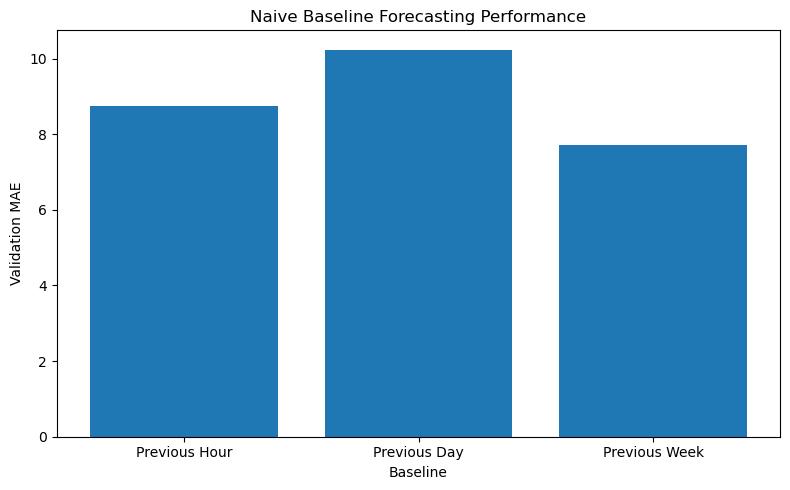

In [54]:
plt.figure(figsize=(8, 5))

plt.bar(
    baseline_results["Model"],
    baseline_results["MAE"]
)

plt.title("Naive Baseline Forecasting Performance")
plt.xlabel("Baseline")
plt.ylabel("Validation MAE")
plt.tight_layout()
plt.show()

**Observation:** The previous-week baseline provides the strongest naive forecast, with a validation MAE of 7.71 pickups per zone-hour and RMSE of 20.89. It outperforms both the previous-hour baseline (MAE 8.76) and previous-day baseline (MAE 10.24).

The stronger weekly baseline indicates that demand is closely tied to recurring hour-of-week patterns rather than simple day-to-day persistence. A learned forecasting model should therefore improve upon the previous-week MAE of 7.71 to demonstrate value beyond a simple historical forecasting rule.

## 6. Define Modeling Features

Define the predictor set and target variable used for machine learning models. The initial feature set combines location, calendar information, and historical demand while excluding the prediction timestamp itself.

In [55]:
features = [
    "PULocationID",
    "hour",
    "day_of_week",
    "month",
    "day_of_month",
    "is_weekend",
    "is_holiday",
    "lag_1",
    "lag_24",
    "lag_168",
    "rolling_mean_24",
    "rolling_mean_168"
]

target = "trip_count"

In [56]:
X_train = train[features]
y_train = train[target]

X_validation = validation[features]
y_validation = validation[target]

X_test = test[features]
y_test = test[target]

print("Training features:", X_train.shape)
print("Validation features:", X_validation.shape)
print("Test features:", X_test.shape)

Training features: (1110816, 12)
Validation features: (254736, 12)
Test features: (129456, 12)


## 7. Train Linear Regression Benchmark

Train a linear regression model as the first learned forecasting benchmark. This provides a simple and interpretable comparison against the naive historical forecasts before introducing models capable of representing nonlinear demand relationships.

In [57]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_validation)

In [58]:
print("Minimum prediction:", linear_predictions.min())
print("Negative predictions:", (linear_predictions < 0).sum())

Minimum prediction: -6.618577817565488
Negative predictions: 22938


In [59]:
linear_metrics = evaluate_forecast(
    y_validation,
    linear_predictions
)

linear_metrics

{'MAE': 6.521040439670282, 'RMSE': np.float64(15.808282674525232)}

**Observation:** Linear regression improves validation performance to an MAE of 6.52 and RMSE of 15.81, outperforming the strongest naive baseline of 7.71 MAE. This represents approximately a 15% reduction in average absolute error compared with simply using demand from the same hour one week earlier.

However, the model produces 22,938 negative demand predictions, including values as low as -6.62. Because pickup counts cannot be negative, this highlights a limitation of applying unconstrained linear regression to count-based demand and motivates testing nonlinear models better suited to complex demand relationships.

## 8. Train Random Forest Model

Train a Random Forest regressor to capture nonlinear relationships and interactions among location, calendar, and historical demand features. Unlike linear regression, the model can learn different demand patterns across zones and time periods without assuming a single linear relationship between each predictor and demand.

In [60]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=20, min_samples_leaf=5, n_jobs=-1,
                      random_state=42)

In [61]:
rf_predictions = rf_model.predict(X_validation)

rf_metrics = evaluate_forecast(
    y_validation,
    rf_predictions
)

rf_metrics

{'MAE': 5.483263942244566, 'RMSE': np.float64(13.519893929576991)}

In [62]:
print("Minimum prediction:", rf_predictions.min())
print("Negative predictions:", (rf_predictions < 0).sum())

Minimum prediction: 0.011225937345033013
Negative predictions: 0


## 9. Compare Model Performance

Compare the learned models against the strongest naive forecasting baseline using validation MAE and RMSE.

In [63]:
model_results = pd.DataFrame([
    {
        "Model": "Previous Week",
        "MAE": baseline_results.loc[
            baseline_results["Model"] == "Previous Week", "MAE"
        ].iloc[0],
        "RMSE": baseline_results.loc[
            baseline_results["Model"] == "Previous Week", "RMSE"
        ].iloc[0]
    },
    {
        "Model": "Linear Regression",
        **linear_metrics
    },
    {
        "Model": "Random Forest",
        **rf_metrics
    }
])

model_results

,Model,MAE,RMSE
0,Previous Week,7.710964,20.886584
1,Linear Regression,6.521040,15.808283
2,Random Forest,5.483264,13.519894


**Observation:** Random Forest provides the strongest validation performance, reducing MAE to 5.48 pickups per zone-hour and RMSE to 13.52. This represents approximately a 29% reduction in MAE relative to the strongest naive baseline and a 16% reduction relative to linear regression.

The improvement suggests that Yellow Taxi demand contains nonlinear relationships and interactions that are not fully captured by a linear model. Random Forest also produces no negative demand forecasts, avoiding the unrealistic predictions observed with linear regression.

## 10. Examine Random Forest Feature Importance

Examine the relative importance assigned to each predictor by the Random Forest model to understand which features contribute most strongly to its forecasts.

In [64]:
feature_importance = (
    pd.DataFrame({
        "feature": features,
        "importance": rf_model.feature_importances_
    })
    .sort_values("importance", ascending=False)
)

feature_importance

,feature,importance
9,lag_168,0.827886
7,lag_1,0.138917
8,lag_24,0.014451
1,hour,0.004604
10,rolling_mean_24,0.003397
11,rolling_mean_168,0.003135
2,day_of_week,0.001987
4,day_of_month,0.001913
0,PULocationID,0.001849
3,month,0.001436


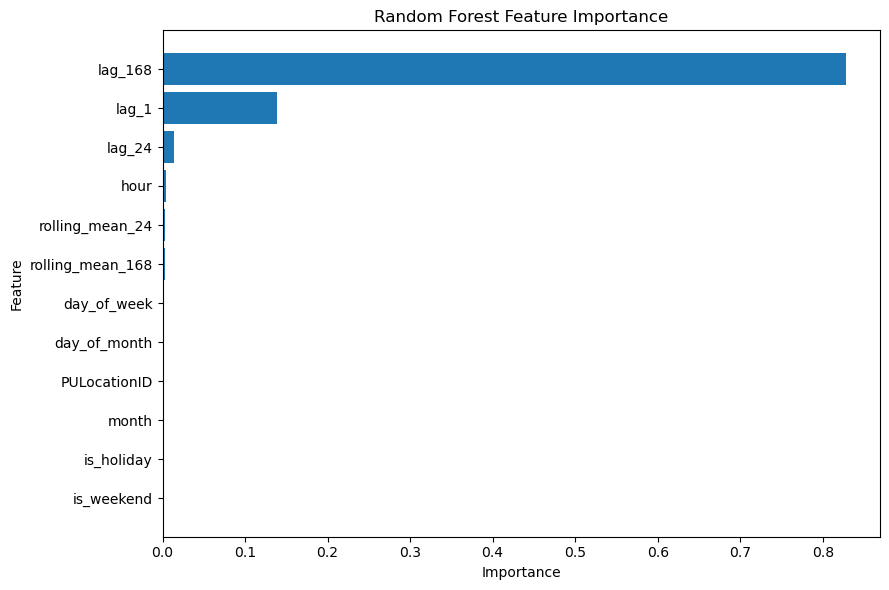

In [65]:
plt.figure(figsize=(9, 6))

plt.barh(
    feature_importance["feature"][::-1],
    feature_importance["importance"][::-1]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

**Observation:** Random Forest feature importance is dominated by the 168-hour lag, with the previous-hour lag providing the second-largest contribution. This reinforces the strong weekly recurrence identified by the naive baseline analysis, suggesting that demand at the same zone and hour one week earlier provides particularly strong predictive information.

The remaining features receive substantially lower impurity-based importance. These values describe how the fitted Random Forest uses predictors and should not be interpreted as causal effects or definitive measures of each feature's independent value.

## 11. Analyze Validation Errors

Examine the distribution and temporal structure of Random Forest forecast errors to identify conditions under which model performance deteriorates.

In [66]:
validation_results = validation[
    ["pickup_hour", "PULocationID", "trip_count"]
].copy()

validation_results["prediction"] = rf_predictions

validation_results["error"] = (
    validation_results["trip_count"] -
    validation_results["prediction"]
)

validation_results["absolute_error"] = (
    validation_results["error"].abs()
)

validation_results.head()

,pickup_hour,PULocationID,trip_count,prediction,error,absolute_error
6384,2025-10-01 00:00:00,4,14,12.111069,1.888931,1.888931
6385,2025-10-01 01:00:00,4,9,10.003048,-1.003048,1.003048
6386,2025-10-01 02:00:00,4,8,9.128572,-1.128572,1.128572
6387,2025-10-01 03:00:00,4,3,3.224831,-0.224831,0.224831
6388,2025-10-01 04:00:00,4,1,4.546638,-3.546638,3.546638


In [67]:
validation_results["absolute_error"].describe()

count    254736.000000
mean          5.483264
std          12.358072
min           0.000005
25%           0.658717
50%           1.611134
75%           4.552619
max         619.508646
Name: absolute_error, dtype: float64

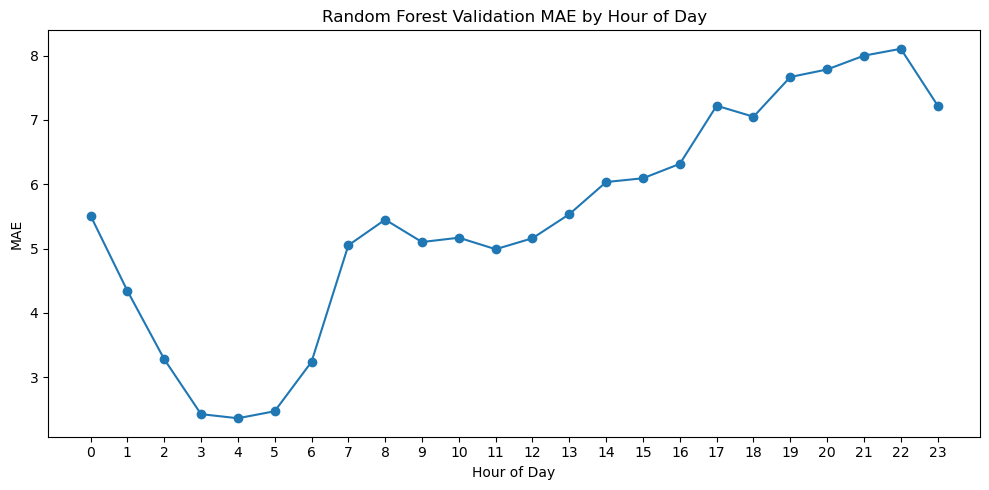

In [68]:
error_by_hour = (
    validation_results
    .assign(hour=validation_results["pickup_hour"].dt.hour)
    .groupby("hour")["absolute_error"]
    .mean()
)

plt.figure(figsize=(10, 5))
plt.plot(
    error_by_hour.index,
    error_by_hour.values,
    marker="o"
)

plt.title("Random Forest Validation MAE by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("MAE")
plt.xticks(range(24))
plt.tight_layout()
plt.show()

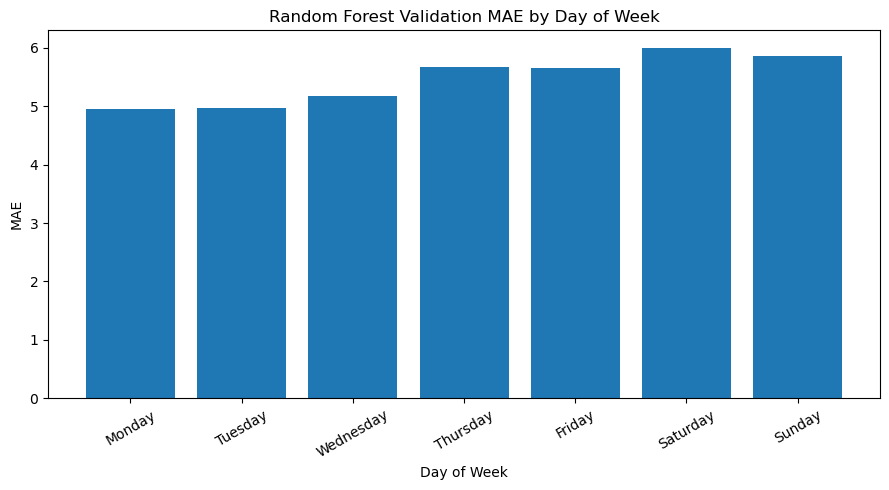

In [69]:
validation_results["day_of_week"] = (
    validation_results["pickup_hour"].dt.dayofweek
)

error_by_day = (
    validation_results
    .groupby("day_of_week")["absolute_error"]
    .mean()
    .reindex(range(7))
)

day_names = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

plt.figure(figsize=(9, 5))
plt.bar(day_names, error_by_day.values)

plt.title("Random Forest Validation MAE by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("MAE")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Observation:** Most Random Forest forecasts are highly accurate, with a median absolute error of 1.61 pickups and 75% of predictions within 4.55 pickups of observed demand. However, the error distribution contains a long upper tail, with occasional errors exceeding several hundred pickups.

Forecast errors are lowest during low-demand early-morning hours and increase substantially during the afternoon and evening, when taxi activity is higher and more variable. Average error is also somewhat higher later in the week and on weekends. These results suggest that much of the remaining forecasting difficulty is concentrated in high-demand and unusually volatile periods rather than being distributed uniformly across observations.

## 12. Train Gradient Boosting Model

Train a histogram-based gradient boosting regressor as a second nonlinear forecasting model. Unlike Random Forest, which averages independently trained trees, gradient boosting builds trees sequentially so that later trees focus on correcting errors remaining from earlier stages.

This provides a useful comparison for determining whether sequential boosting can better capture complex demand patterns and reduce the larger errors observed in the Random Forest forecasts.

In [70]:
gb_model = HistGradientBoostingRegressor(
    learning_rate=0.1,
    max_iter=200,
    max_leaf_nodes=31,
    l2_regularization=1.0,
    random_state=42
)

gb_model.fit(X_train, y_train)

HistGradientBoostingRegressor(l2_regularization=1.0, max_iter=200,
                              random_state=42)

In [71]:
gb_predictions = gb_model.predict(X_validation)

gb_metrics = evaluate_forecast(
    y_validation,
    gb_predictions
)

gb_metrics

{'MAE': 5.592519769427114, 'RMSE': np.float64(13.417599130517637)}

In [72]:
print("Minimum prediction:", gb_predictions.min())
print("Negative predictions:", (gb_predictions < 0).sum())

Minimum prediction: -19.79940898389672
Negative predictions: 23


## 13. Compare Validation Performance

Compare validation performance across the naive baseline and learned forecasting models before selecting a final model for held-out test evaluation.

In [73]:
model_results = pd.DataFrame([
    {
        "Model": "Previous Week",
        "MAE": baseline_results.loc[
            baseline_results["Model"] == "Previous Week", "MAE"
        ].iloc[0],
        "RMSE": baseline_results.loc[
            baseline_results["Model"] == "Previous Week", "RMSE"
        ].iloc[0]
    },
    {
        "Model": "Linear Regression",
        **linear_metrics
    },
    {
        "Model": "Random Forest",
        **rf_metrics
    },
    {
        "Model": "Gradient Boosting",
        **gb_metrics
    }
])

model_results

,Model,MAE,RMSE
0,Previous Week,7.710964,20.886584
1,Linear Regression,6.521040,15.808283
2,Random Forest,5.483264,13.519894
3,Gradient Boosting,5.592520,13.417599


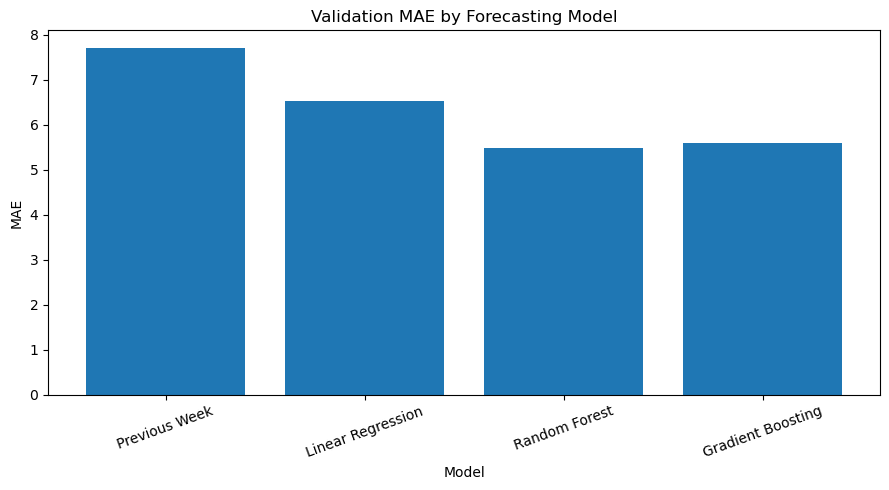

In [74]:
plt.figure(figsize=(9, 5))

plt.bar(
    model_results["Model"],
    model_results["MAE"]
)

plt.title("Validation MAE by Forecasting Model")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Observation:** Random Forest achieves the lowest validation MAE at 5.48 pickups per zone-hour, while Gradient Boosting achieves a slightly lower RMSE of 13.42 compared with 13.52 for Random Forest. The small RMSE advantage suggests that Gradient Boosting handles some larger errors slightly better, but its average absolute error is approximately 2% higher and it produces 23 negative demand predictions.

Because MAE is the primary evaluation metric and directly represents the average number of pickups missed per zone-hour, Random Forest is selected as the final model based on validation performance. The held-out December test period has not been used in this selection.

## 14. Retrain Selected Model

After selecting Random Forest using validation performance, combine the training and validation periods and refit the selected model using all observations available before the held-out December test period.

The test period remains untouched during model selection and training configuration decisions.

In [75]:
train_validation = pd.concat(
    [train, validation],
    ignore_index=True
)

X_train_validation = train_validation[features]
y_train_validation = train_validation[target]

print("Training rows:", f"{len(train_validation):,}")
print(
    "Training period:",
    train_validation["pickup_hour"].min(),
    "to",
    train_validation["pickup_hour"].max()
)

Training rows: 1,365,552
Training period: 2025-01-08 00:00:00 to 2025-11-30 23:00:00


In [76]:
final_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)

final_model.fit(
    X_train_validation,
    y_train_validation
)

RandomForestRegressor(max_depth=20, min_samples_leaf=5, n_jobs=-1,
                      random_state=42)

## 15. Evaluate Final Model on Held-Out Test Data

Evaluate the selected Random Forest model once on the untouched December 2025 test period. This provides the final estimate of forecasting performance on future data not used for model selection.

In [77]:
test_predictions = final_model.predict(X_test)

test_metrics = evaluate_forecast(
    y_test,
    test_predictions
)

test_metrics

{'MAE': 5.715772544438479, 'RMSE': np.float64(14.008350766468487)}

In [78]:
print("Minimum prediction:", test_predictions.min())
print("Negative predictions:", (test_predictions < 0).sum())

Minimum prediction: 0.0041474735312984744
Negative predictions: 0


In [79]:
test_baseline_metrics = evaluate_forecast(
    y_test,
    test["lag_168"]
)

test_comparison = pd.DataFrame([
    {
        "Model": "Previous Week Baseline",
        **test_baseline_metrics
    },
    {
        "Model": "Random Forest",
        **test_metrics
    }
])

test_comparison

,Model,MAE,RMSE
0,Previous Week Baseline,11.395864,31.720802
1,Random Forest,5.715773,14.008351


In [80]:
mae_improvement = (
    (
        test_baseline_metrics["MAE"] -
        test_metrics["MAE"]
    )
    / test_baseline_metrics["MAE"]
    * 100
)

rmse_improvement = (
    (
        test_baseline_metrics["RMSE"] -
        test_metrics["RMSE"]
    )
    / test_baseline_metrics["RMSE"]
    * 100
)

print(f"MAE improvement over baseline: {mae_improvement:.1f}%")
print(f"RMSE improvement over baseline: {rmse_improvement:.1f}%")

MAE improvement over baseline: 49.8%
RMSE improvement over baseline: 55.8%


**Observation:** The final Random Forest achieves an MAE of 5.72 pickups per zone-hour and RMSE of 14.01 on the untouched December test period. Performance remains close to the validation results, where the model achieved an MAE of 5.48 and RMSE of 13.52, indicating relatively stable performance on future observations.

The previous-week baseline deteriorates substantially during December, reaching an MAE of 11.40 and RMSE of 31.72. Relative to this baseline, the final Random Forest reduces MAE by 49.8% and RMSE by 55.8%. The model also produces no negative demand predictions.

## 16. Analyze Final Test Errors

Examine the distribution of forecasting errors on the held-out test period and compare predicted and observed demand to better understand final model behavior. The visualization is restricted to absolute errors between 0 and 50 pickups so that the distribution of typical forecast errors remains visible despite a small number of extreme errors.

In [81]:
test_results = test[
    ["pickup_hour", "PULocationID", "trip_count"]
].copy()

test_results["prediction"] = test_predictions

test_results["error"] = (
    test_results["trip_count"] -
    test_results["prediction"]
)

test_results["absolute_error"] = (
    test_results["error"].abs()
)

test_results["absolute_error"].describe()

count    129456.000000
mean          5.715773
std          12.789257
min           0.000008
25%           0.694442
50%           1.699848
75%           4.753367
max         532.808970
Name: absolute_error, dtype: float64

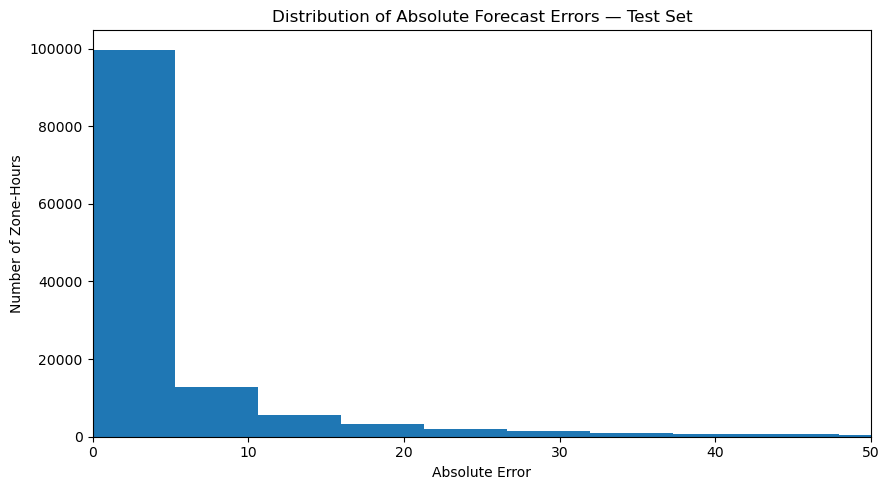

In [82]:
plt.figure(figsize=(9, 5))

plt.hist(
    test_results["absolute_error"],
    bins=100
)

plt.title("Distribution of Absolute Forecast Errors — Test Set")
plt.xlabel("Absolute Error")
plt.ylabel("Number of Zone-Hours")
plt.xlim(0, 50)
plt.tight_layout()
plt.show()

## 17. Compare Predicted and Observed Demand

Aggregate zone-level forecasts to daily citywide demand to visualize whether the final model captures broader changes in taxi activity throughout the held-out test period.

In [83]:
daily_test = (
    test_results
    .assign(date=test_results["pickup_hour"].dt.date)
    .groupby("date")[["trip_count", "prediction"]]
    .sum()
    .reset_index()
)

daily_test["date"] = pd.to_datetime(daily_test["date"])

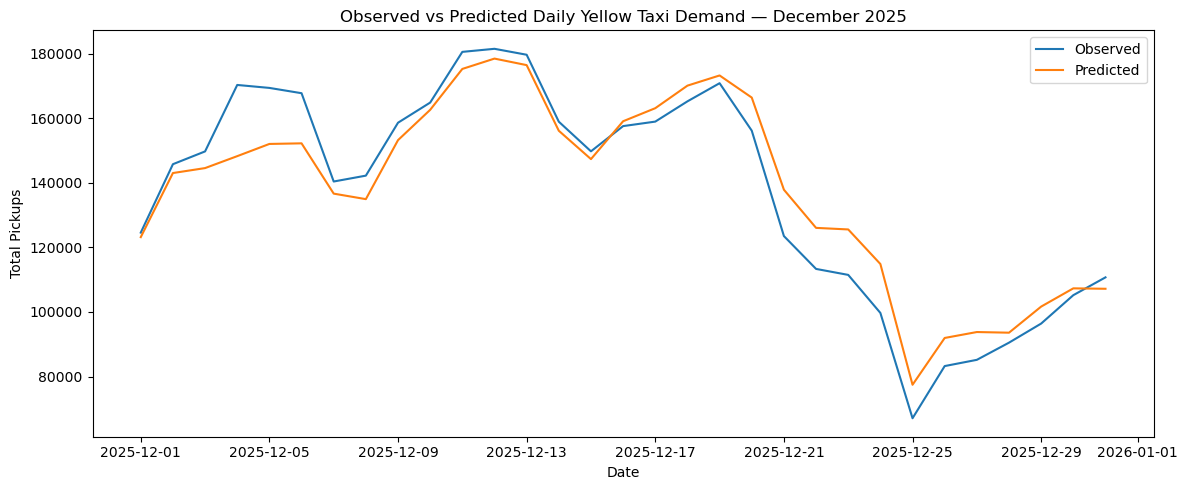

In [84]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_test["date"],
    daily_test["trip_count"],
    label="Observed"
)

plt.plot(
    daily_test["date"],
    daily_test["prediction"],
    label="Predicted"
)

plt.title("Observed vs Predicted Daily Yellow Taxi Demand — December 2025")
plt.xlabel("Date")
plt.ylabel("Total Pickups")
plt.legend()
plt.tight_layout()
plt.show()

**Observation:** Test errors are strongly right-skewed, with most zone-hour forecasts producing relatively small absolute errors and a much smaller number of observations accounting for the largest misses. At the citywide daily level, the model captures the overall December demand pattern, including the mid-month peak and substantial decline around Christmas.

The largest systematic deviations occur during periods when demand changes unusually quickly. The model underpredicts the early-December increase and overpredicts portions of the late-December decline, suggesting that historical demand patterns alone cannot fully anticipate abrupt changes in travel behavior. External features such as weather or more detailed holiday and event information may help explain some of this remaining variation.

## 18. Save Final Model

Save the final Random Forest model so the trained forecasting pipeline can be reused without retraining from the full historical dataset.

In [85]:
models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)

model_path = models_dir / "random_forest_taxi_demand.joblib"

joblib.dump(final_model, model_path)

print(f"Saved model to: {model_path}")

Saved model to: ../models/random_forest_taxi_demand.joblib


## 19. Key Findings

**Observation:** Chronological validation showed that learned models outperform simple historical forecasting rules for one-hour-ahead zone-level Yellow Taxi demand. Random Forest achieved the lowest validation MAE at 5.48 pickups per zone-hour and was selected before examining the held-out test period.

After retraining on all available January through November observations, the final Random Forest achieved an MAE of 5.72 and RMSE of 14.01 on the untouched December test set. This reduced MAE by 49.8% and RMSE by 55.8% relative to the previous-week baseline while producing no negative demand predictions.

Historical demand one week earlier was the most influential Random Forest feature, reinforcing the strong weekly structure observed throughout the project. Error analysis showed that most zone-hour predictions have relatively small errors, while a smaller number of volatile periods account for disproportionately large misses. At the daily level, the model captures the broader December demand trajectory but responds less accurately to abrupt changes, particularly around the holiday period. This provides a clear direction for future experimentation with external features such as weather and more detailed event information.

In [86]:
# Create hourly December forecast dataframe
december_forecast = test[["pickup_hour", "trip_count"]].copy()
december_forecast["prediction"] = test_predictions

# Aggregate across all 174 pickup zones
december_hourly = (
    december_forecast
    .groupby("pickup_hour", as_index=False)
    .agg(
        actual_demand=("trip_count", "sum"),
        predicted_demand=("prediction", "sum")
    )
)

print("Hours:", len(december_hourly))
display(december_hourly.head())

Hours: 744


,pickup_hour,actual_demand,predicted_demand
0,2025-12-01 00:00:00,2199,2028.999123
1,2025-12-01 01:00:00,1199,1259.553586
2,2025-12-01 02:00:00,602,767.310277
3,2025-12-01 03:00:00,421,463.413923
4,2025-12-01 04:00:00,605,624.783159


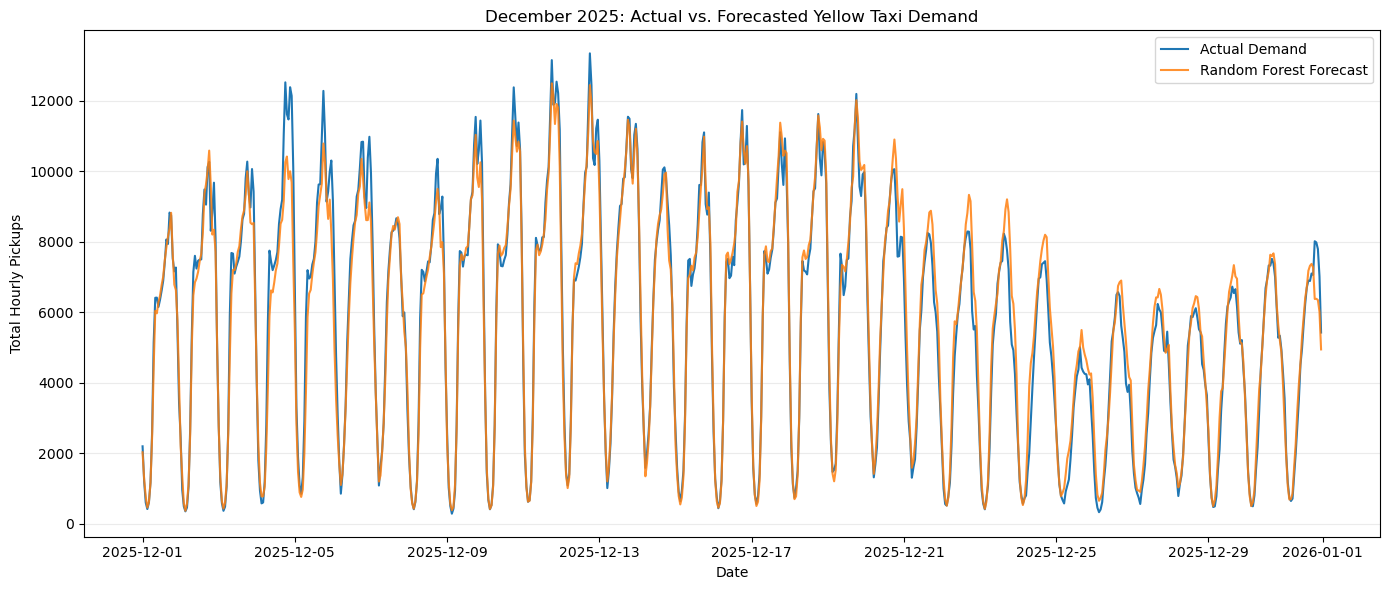

In [88]:
plt.figure(figsize=(14, 6))

plt.plot(

    december_hourly["pickup_hour"],

    december_hourly["actual_demand"],

    label="Actual Demand",

    linewidth=1.5

)

plt.plot(

    december_hourly["pickup_hour"],

    december_hourly["predicted_demand"],

    label="Random Forest Forecast",

    linewidth=1.5,

    alpha=0.85

)

plt.xlabel("Date")

plt.ylabel("Total Hourly Pickups")

plt.title("December 2025: Actual vs. Forecasted Yellow Taxi Demand")

plt.legend()

plt.grid(axis="y", alpha=0.25)

plt.tight_layout()

plt.savefig(

    figures_dir / "december_forecast.png",

    dpi=200,

    bbox_inches="tight"

)

plt.show()

**Observation:** The Random Forest closely tracked the overall hourly demand pattern throughout December, including recurring daily and weekly fluctuations. Larger errors occurred during several abrupt demand shifts, particularly around the early-December surge and the late-December holiday period, but the model generally captured the direction and magnitude of demand across the month.

The final model achieved a December MAE of 5.72 pickups per zone-hour and RMSE of 14.01, reducing error substantially relative to the previous-week persistence baseline.

## Streamlit Export

To support interactive zone-level forecast exploration, the final December predictions are exported as a lightweight dataset for the Streamlit application.

In [89]:
from pathlib import Path

app_data_dir = Path("../data/app")
app_data_dir.mkdir(parents=True, exist_ok=True)

december_predictions = test[
    ["pickup_hour", "PULocationID", "trip_count"]
].copy()

december_predictions["prediction"] = test_predictions

december_predictions.to_parquet(
    app_data_dir / "december_predictions.parquet",
    index=False
)

print("Rows exported:", len(december_predictions))
print("Zones:", december_predictions["PULocationID"].nunique())
print(
    "Date range:",
    december_predictions["pickup_hour"].min(),
    "to",
    december_predictions["pickup_hour"].max()
)

Rows exported: 129456
Zones: 174
Date range: 2025-12-01 00:00:00 to 2025-12-31 23:00:00
